# H2 — Biais en mode comparatif (face-à-face)

**Hypothèse :** Lorsqu'un LLM doit choisir entre deux CV identiques dont seul le nom
(français vs minorité) diffère, la probabilité de choisir le candidat français est
significativement supérieure à 0,5 (hasard).

**Colonne cible :** `chose_majorite` (1 = CV français sélectionné, 0 = CV minorité sélectionné)

**Lecture des axes :**
- Axe vertical : P(français choisi) — la ligne rouge à 0,5 est la référence du hasard.
- Au-dessus de 0,5 → préférence pour le candidat français (biais pro-majorité).
- En-dessous de 0,5 → préférence pour le candidat minoritaire.


In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *

set_style()

df = charger_behavioral()
MODELES = modeles_tries(df)

comp = df[df.eval_mode == 'comparative'].dropna(subset=['chose_majorite']).copy()
# Ne garder que les modèles qui ont des données comparatives
modeles_comp = [m for m in MODELES if m in comp['model'].unique()]
comp = comp[comp['model'].isin(modeles_comp)].copy()

print(f"Modèles avec données comparatives : {modeles_comp}")
print(f"N total lignes comp : {len(comp)}")


Modèles avec données comparatives : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita']
N total lignes comp : 1304


## Exploration — P(français choisi) par modèle × minorité


In [2]:
# Tableau P(français choisi) + N par cellule
pivot_mean = (
    comp.groupby(['model', 'condition'])['chose_majorite']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'P(français choisi)', 'count': 'N'})
    .round(3)
)
pivot_mean.columns.name = None
display(pivot_mean)


P(français choisi)    N
model               condition                         
Gemma-4-31B-it      african                 0.500  200
                    maghrebin               0.500  200
Mistral-Nemo-Novita african                 0.434   53
                    maghrebin               0.435   62
Qwen3.6-27B-FP8     african                 0.497  199
                    maghrebin               0.500  200
Qwen3.7-max-Novita  african                 0.500  194
                    maghrebin               0.495  196

## Tests statistiques — binomial vs 0,5 par modèle × minorité


In [3]:
from scipy.stats import binomtest

rows = []
for m in modeles_comp:
    for eth in MIN:
        sub = comp[(comp.model == m) & (comp.condition == eth)]
        n = len(sub)
        k = int(sub['chose_majorite'].sum())
        if n == 0:
            continue
        res = binomtest(k, n, p=0.5, alternative='two-sided')
        rows.append({
            'Modèle': m,
            'Minorité': ETIQ_ETH[eth],
            'N': n,
            'P(fr choisi)': round(k / n, 3),
            'p-value': round(res.pvalue, 4),
            'Sig.': '★' if res.pvalue < 0.05 else ''
        })

tab_tests = pd.DataFrame(rows)
display(tab_tests)


,Modèle,Minorité,N,P(fr choisi),p-value,Sig.
0,Mistral-Nemo-Novita,Maghrébin,62,0.435,0.3742,
1,Mistral-Nemo-Novita,Africain,53,0.434,0.4101,
2,Qwen3.6-27B-FP8,Maghrébin,200,0.500,1.0000,
3,Qwen3.6-27B-FP8,Africain,199,0.497,1.0000,
4,Gemma-4-31B-it,Maghrébin,200,0.500,1.0000,
5,Gemma-4-31B-it,Africain,200,0.500,1.0000,
6,Qwen3.7-max-Novita,Maghrébin,196,0.495,0.9431,
7,Qwen3.7-max-Novita,Africain,194,0.500,1.0000,


In [4]:
def ic_proportion(sub, col='chose_majorite', conf=0.95):
    # Renvoie (mean, low, high) avec IC binomial Wilson
    n = len(sub)
    k = int(sub[col].sum())
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    # Wilson score interval
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, center - margin, center + margin


### Variante 1 — Barres groupées (modèle × minorité)


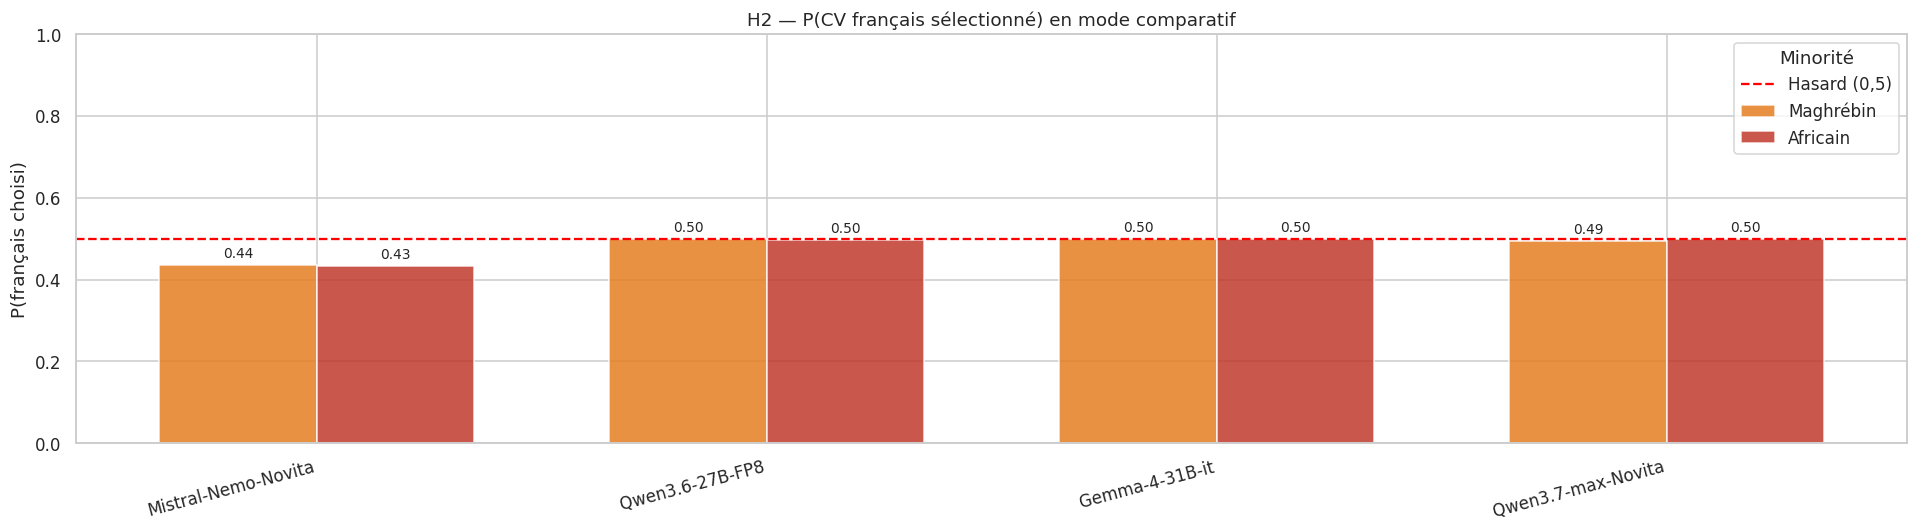

In [5]:
fig, ax = plt.subplots(figsize=(max(7, 2.2 * len(modeles_comp) * len(MIN)), 5))

x = np.arange(len(modeles_comp))
width = 0.35
offsets = [-width / 2, width / 2]

for i, eth in enumerate(MIN):
    vals = []
    for m in modeles_comp:
        sub = comp[(comp.model == m) & (comp.condition == eth)]
        vals.append(sub['chose_majorite'].mean() if len(sub) else np.nan)

    bars = ax.bar(
        x + offsets[i], vals, width,
        label=ETIQ_ETH[eth],
        color=COUL_ETH[eth],
        alpha=0.85,
        edgecolor='white'
    )

    # Annotations et étoiles
    for j, (bar, m) in enumerate(zip(bars, modeles_comp)):
        sub = comp[(comp.model == m) & (comp.condition == eth)]
        n = len(sub)
        k = int(sub['chose_majorite'].sum()) if n else 0
        pval = binomtest(k, n, p=0.5).pvalue if n else 1.0
        star = '★' if pval < 0.05 else ''
        v = bar.get_height()
        if not np.isnan(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.01,
                f"{v:.2f}{star}",
                ha='center', va='bottom', fontsize=9
            )

ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Hasard (0,5)')
ax.set_xticks(x)
ax.set_xticklabels(modeles_comp, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('P(français choisi)')
ax.set_title('H2 — P(CV français sélectionné) en mode comparatif')
ax.legend(title='Minorité')
plt.tight_layout()
plt.show()


### Variante 2 — Dot plot avec IC binomial (Wilson)


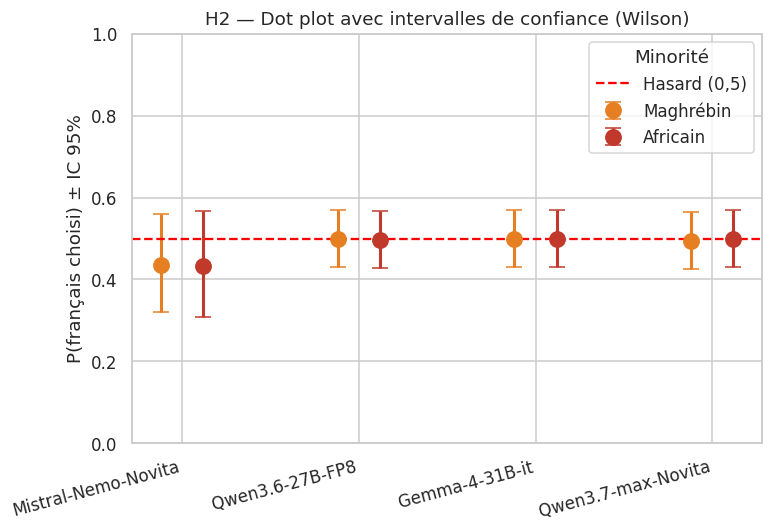

In [6]:
fig, ax = plt.subplots(figsize=(max(6, 1.8 * len(modeles_comp)), 5))

jitter_vals = {MIN[0]: -0.12, MIN[1]: 0.12}

for eth in MIN:
    xs, ys, y_lo, y_hi = [], [], [], []
    for j, m in enumerate(modeles_comp):
        sub = comp[(comp.model == m) & (comp.condition == eth)]
        if len(sub) == 0:
            continue
        p, lo, hi = ic_proportion(sub)
        xs.append(j + jitter_vals[eth])
        ys.append(p)
        y_lo.append(p - lo)
        y_hi.append(hi - p)

    ax.errorbar(
        xs, ys,
        yerr=[y_lo, y_hi],
        fmt='o', markersize=10,
        color=COUL_ETH[eth],
        ecolor=COUL_ETH[eth],
        elinewidth=2, capsize=5,
        label=ETIQ_ETH[eth]
    )

    # Annotations étoiles
    for j, m in enumerate(modeles_comp):
        sub = comp[(comp.model == m) & (comp.condition == eth)]
        n = len(sub)
        if n == 0:
            continue
        k = int(sub['chose_majorite'].sum())
        pval = binomtest(k, n, p=0.5).pvalue
        if pval < 0.05:
            p, _, _ = ic_proportion(sub)
            ax.text(
                j + jitter_vals[eth], p + 0.04,
                '★', ha='center', va='bottom',
                color=COUL_ETH[eth], fontsize=13
            )

ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Hasard (0,5)')
ax.set_xticks(range(len(modeles_comp)))
ax.set_xticklabels(modeles_comp, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('P(français choisi) ± IC 95%')
ax.set_title('H2 — Dot plot avec intervalles de confiance (Wilson)')
ax.legend(title='Minorité')
plt.tight_layout()
plt.show()


### Variante 3 — Barres divergentes centrées sur 0,5


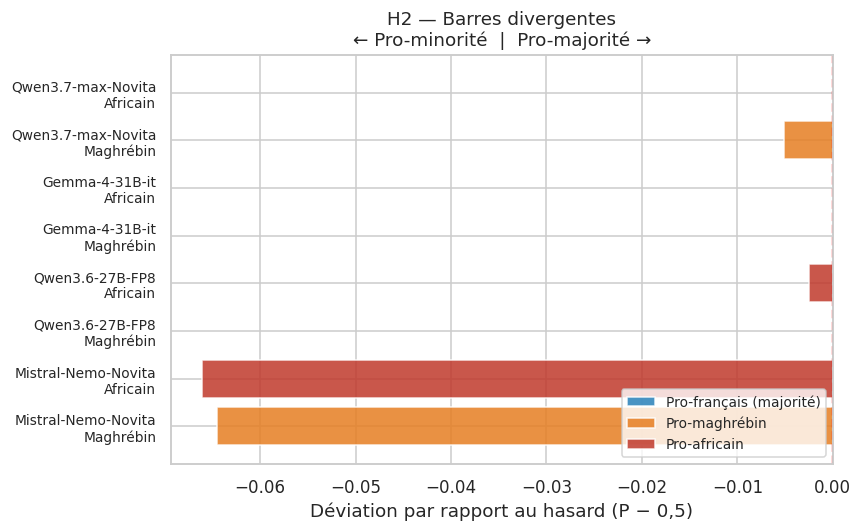

In [7]:
# Barres divergentes : déviation par rapport à 0,5
# Positif (à droite) = pro-majorité, négatif (à gauche) = pro-minorité

categories = [(m, eth) for m in modeles_comp for eth in MIN]
labels = [f"{m}\n{ETIQ_ETH[eth]}" for m, eth in categories]
deviations = []
colors = []
stars = []

for m, eth in categories:
    sub = comp[(comp.model == m) & (comp.condition == eth)]
    if len(sub) == 0:
        deviations.append(0)
        colors.append('#cccccc')
        stars.append('')
        continue
    p = sub['chose_majorite'].mean()
    dev = p - 0.5
    deviations.append(dev)
    colors.append(COUL_ETH['french'] if dev >= 0 else COUL_ETH[eth])
    n = len(sub)
    k = int(sub['chose_majorite'].sum())
    pval = binomtest(k, n, p=0.5).pvalue
    stars.append('★' if pval < 0.05 else '')

y_pos = np.arange(len(categories))
fig, ax = plt.subplots(figsize=(8, max(5, 0.5 * len(categories))))

bars = ax.barh(y_pos, deviations, color=colors, alpha=0.85, edgecolor='white')

for bar, star, dev in zip(bars, stars, deviations):
    if star:
        x_txt = dev + (0.01 if dev >= 0 else -0.01)
        ha = 'left' if dev >= 0 else 'right'
        ax.text(x_txt, bar.get_y() + bar.get_height() / 2,
                star, va='center', ha=ha, fontsize=13)

ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Déviation par rapport au hasard (P − 0,5)')
ax.set_title('H2 — Barres divergentes\n← Pro-minorité  |  Pro-majorité →')

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COUL_ETH['french'], alpha=0.85, label='Pro-français (majorité)'),
    Patch(facecolor=COUL_ETH['maghrebin'], alpha=0.85, label='Pro-maghrébin'),
    Patch(facecolor=COUL_ETH['african'], alpha=0.85, label='Pro-africain'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


## Contrôle d'ordre de présentation

Vérification que le biais n'est pas un artefact de position dans le prompt
(french_first = CV français présenté en premier, minority_first = CV minorité en premier).


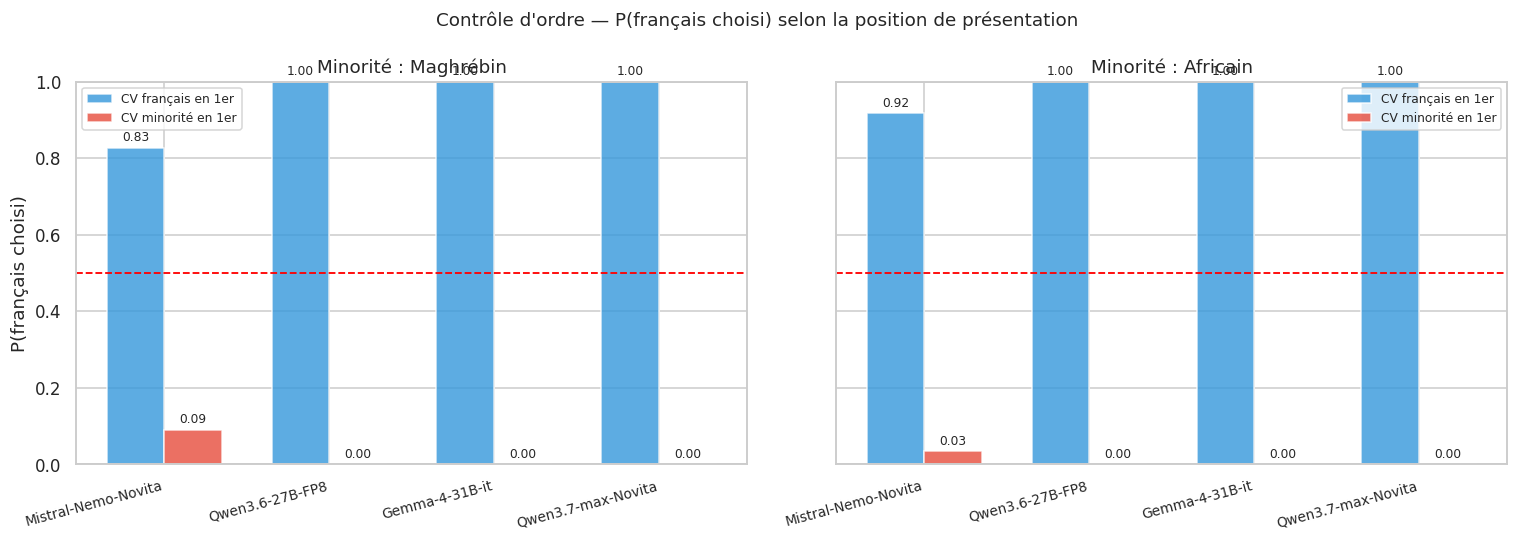

In [8]:
# P(français choisi) par modèle × minorité × order
order_vals = comp['order'].dropna().unique().tolist()

fig, axes = plt.subplots(
    1, len(MIN),
    figsize=(max(6, 3.5 * len(modeles_comp)), 5),
    sharey=True
)
if len(MIN) == 1:
    axes = [axes]

for ax, eth in zip(axes, MIN):
    sub_eth = comp[comp.condition == eth]
    x = np.arange(len(modeles_comp))
    width = 0.35
    order_colors = {'french_first': '#3498DB', 'minority_first': '#E74C3C'}
    order_labels = {'french_first': 'CV français en 1er', 'minority_first': 'CV minorité en 1er'}
    offsets = list(zip([-width / 2, width / 2], order_vals))

    for offset, order in offsets:
        vals = []
        for m in modeles_comp:
            s = sub_eth[(sub_eth.model == m) & (sub_eth.order == order)]
            vals.append(s['chose_majorite'].mean() if len(s) else np.nan)

        bars = ax.bar(
            x + offset, vals, width,
            label=order_labels.get(order, order),
            color=order_colors.get(order, '#999'),
            alpha=0.8, edgecolor='white'
        )
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    v + 0.01,
                    f"{v:.2f}",
                    ha='center', va='bottom', fontsize=8
                )

    ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(modeles_comp, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Minorité : {ETIQ_ETH[eth]}')
    ax.set_ylabel('P(français choisi)' if eth == MIN[0] else '')
    ax.legend(fontsize=8)

fig.suptitle("Contrôle d'ordre — P(français choisi) selon la position de présentation",
             fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# Tableau numérique contrôle d'ordre
rows_order = []
for m in modeles_comp:
    for eth in MIN:
        for order in comp['order'].dropna().unique():
            s = comp[(comp.model == m) & (comp.condition == eth) & (comp.order == order)]
            if len(s) == 0:
                continue
            rows_order.append({
                'Modèle': m,
                'Minorité': ETIQ_ETH[eth],
                'Ordre': order,
                'N': len(s),
                'P(fr choisi)': round(s['chose_majorite'].mean(), 3)
            })

tab_order = pd.DataFrame(rows_order)
display(tab_order.pivot_table(
    index=['Modèle', 'Minorité'],
    columns='Ordre',
    values='P(fr choisi)'
).round(3))


Ordre                          french_first  minority_first
Modèle              Minorité                               
Gemma-4-31B-it      Africain          1.000           0.000
                    Maghrébin         1.000           0.000
Mistral-Nemo-Novita Africain          0.917           0.034
                    Maghrébin         0.828           0.091
Qwen3.6-27B-FP8     Africain          1.000           0.000
                    Maghrébin         1.000           0.000
Qwen3.7-max-Novita  Africain          1.000           0.000
                    Maghrébin         1.000           0.000